## Import das bibliotecas necessárias, acesso aos dados, print da estrutura e formato.

In [ ]:
import pandas
import io
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
file_path = 'Sleep_health_and_lifestyle_dataset.csv'
print(f'Using file: {file_path}')

Using file: /content/Sleep_health_and_lifestyle_dataset.csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID da Pessoa               374 non-null    int64  
 1   Gênero                     374 non-null    int64  
 2   Idade                      374 non-null    float64
 3   Ocupação                   374 non-null    object 
 4   Duração do Sono            374 non-null    float64
 5   Qualidade do Sono          374 non-null    float64
 6   Nível de Atividade Física  374 non-null    float64
 7   Nível de Estresse          374 non-null    float64
 8   Categoria de IMC           353 non-null    object 
 9   Pressão Sanguínea          374 non-null    object 
 10  Frequência Cardíaca        374 non-null    float64
 11  Passos Diários             374 non-null    float64
 12  Distúrbio do Sono          374 non-null    object 
 13  Distúrbio do Sono_encoded  374 non-null    int64  

## Processo de limpeza de dados, inglês para português, métricas de 0 a 1, alterações necessárias para ficar no formato ideal para o algoritmo "entender".

In [ ]:
# Dicionário para traduzir os nomes das colunas
column_translation = {
    'Person ID': 'ID da Pessoa',
    'Gender': 'Gênero',
    'Age': 'Idade',
    'Occupation': 'Ocupação',
    'Sleep Duration': 'Duração do Sono',
    'Quality of Sleep': 'Qualidade do Sono',
    'Physical Activity Level': 'Nível de Atividade Física',
    'Stress Level': 'Nível de Estresse',
    'BMI Category': 'Categoria de IMC',
    'Blood Pressure': 'Pressão Sanguínea',
    'Heart Rate': 'Frequência Cardíaca',
    'Daily Steps': 'Passos Diários',
    'Sleep Disorder': 'Distúrbio do Sono'
}

# Renomear as colunas do DataFrame
df.rename(columns=column_translation, inplace=True)

# Dicionários para traduzir valores específicos em colunas categóricas
gender_map = {
    'Male': 'Masculino',
    'Female': 'Feminino'
}

occupation_map = {
    'Software Engineer': 'Engenheiro de Software',
    'Doctor': 'Médico',
    'Sales Representative': 'Representante de Vendas',
    'Teacher': 'Professor',
    'Nurse': 'Enfermeiro',
    'Engineer': 'Engenheiro',
    'Accountant': 'Contador',
    'Scientist': 'Cientista',
    'Lawyer': 'Advogado',
    'Salesperson': 'Vendedor',
    'Manager': 'Gerente'
}

bmi_map = {
    'Overweight': 'Sobrepeso',
    'Normal': 'Normal',
    'Obese': 'Obeso'
}

sleep_disorder_map = {
    'Sleep Apnea': 'Apneia do Sono',
    'Insomnia': 'Insônia'
}

# Aplicar as traduções aos valores das colunas
df['Gênero'] = df['Gênero'].map(gender_map)
df['Ocupação'] = df['Ocupação'].map(occupation_map)
df['Categoria de IMC'] = df['Categoria de IMC'].map(bmi_map)
df['Distúrbio do Sono'] = df['Distúrbio do Sono'].map(sleep_disorder_map)

# Exibir as primeiras linhas do DataFrame traduzido
df.head()

,ID da Pessoa,Gênero,Idade,Ocupação,Duração do Sono,Qualidade do Sono,Nível de Atividade Física,Nível de Estresse,Categoria de IMC,Pressão Sanguínea,Frequência Cardíaca,Passos Diários,Distúrbio do Sono,Distúrbio do Sono_encoded,Categoria de IMC_encoded
0,1,NaN,0.00000,NaN,0.111111,0.4,0.2,0.6,NaN,126/83,0.571429,0.171429,NaN,2,2
1,2,NaN,0.03125,NaN,0.148148,0.4,0.5,1.0,Normal,125/80,0.476190,1.000000,NaN,2,0
2,3,NaN,0.03125,NaN,0.148148,0.4,0.5,1.0,Normal,125/80,0.476190,1.000000,NaN,2,0
3,4,NaN,0.03125,NaN,0.037037,0.0,0.0,1.0,NaN,140/90,0.952381,0.000000,NaN,0,1
4,5,NaN,0.03125,NaN,0.037037,0.0,0.0,1.0,NaN,140/90,0.952381,0.000000,NaN,0,1


In [ ]:
df['Gênero'] = df['Gênero'].replace({'Masculino': 0, 'Feminino': 1}).infer_objects(copy=False)

df.head()

/tmp/ipykernel_620/1722000071.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gênero'] = df['Gênero'].replace({'Masculino': 0, 'Feminino': 1}).infer_objects(copy=False)


,ID da Pessoa,Gênero,Idade,Ocupação,Duração do Sono,Qualidade do Sono,Nível de Atividade Física,Nível de Estresse,Categoria de IMC,Pressão Sanguínea,Frequência Cardíaca,Passos Diários,Distúrbio do Sono,Distúrbio do Sono_encoded,Categoria de IMC_encoded
0,1,NaN,0.00000,NaN,0.111111,0.4,0.2,0.6,NaN,126/83,0.571429,0.171429,NaN,2,2
1,2,NaN,0.03125,NaN,0.148148,0.4,0.5,1.0,Normal,125/80,0.476190,1.000000,NaN,2,0
2,3,NaN,0.03125,NaN,0.148148,0.4,0.5,1.0,Normal,125/80,0.476190,1.000000,NaN,2,0
3,4,NaN,0.03125,NaN,0.037037,0.0,0.0,1.0,NaN,140/90,0.952381,0.000000,NaN,0,1
4,5,NaN,0.03125,NaN,0.037037,0.0,0.0,1.0,NaN,140/90,0.952381,0.000000,NaN,0,1


In [ ]:
# Selecionar as colunas numéricas a serem normalizadas
# 'ID da Pessoa' e 'Pressão Sanguínea' são excluídos, pois não são variáveis para normalização
columns_to_normalize = ['Idade', 'Duração do Sono', 'Qualidade do Sono',
                        'Nível de Atividade Física', 'Nível de Estresse',
                        'Frequência Cardíaca', 'Passos Diários']

# Inicializar o MinMaxScaler
scaler = MinMaxScaler()

# Aplicar a normalização nas colunas selecionadas
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

# Exibir as primeiras linhas do DataFrame com as colunas normalizadas
df.head()

,ID da Pessoa,Gênero,Idade,Ocupação,Duração do Sono,Qualidade do Sono,Nível de Atividade Física,Nível de Estresse,Categoria de IMC,Pressão Sanguínea,Frequência Cardíaca,Passos Diários,Distúrbio do Sono,Distúrbio do Sono_encoded,Categoria de IMC_encoded
0,1,NaN,0.00000,NaN,0.111111,0.4,0.2,0.6,NaN,126/83,0.571429,0.171429,NaN,2,2
1,2,NaN,0.03125,NaN,0.148148,0.4,0.5,1.0,Normal,125/80,0.476190,1.000000,NaN,2,0
2,3,NaN,0.03125,NaN,0.148148,0.4,0.5,1.0,Normal,125/80,0.476190,1.000000,NaN,2,0
3,4,NaN,0.03125,NaN,0.037037,0.0,0.0,1.0,NaN,140/90,0.952381,0.000000,NaN,0,1
4,5,NaN,0.03125,NaN,0.037037,0.0,0.0,1.0,NaN,140/90,0.952381,0.000000,NaN,0,1


## No mapa de calor abaixo, podemos observar:

Correlações Positivas (tons de vermelho): Quanto mais vermelho e mais próximo de 1.00, mais forte é a relação direta entre as variáveis. Por exemplo, 'Duração do Sono' e 'Qualidade do Sono' mostram uma forte correlação positiva (0.88), o que faz sentido.

Correlações Negativas (tons de azul): Quanto mais azul e mais próximo de -1.00, mais forte é a relação inversa entre as variáveis. Por exemplo, 'Nível de Estresse' tem uma forte correlação negativa com 'Duração do Sono' (-0.81) e 'Qualidade do Sono' (-0.90), sugerindo que quanto maior o estresse, menor a duração e qualidade do sono.

Correlações Fracas (tons claros/cinza): Valores próximos de 0.00 indicam pouca ou nenhuma correlação linear. Por exemplo, 'Passos Diários' tem uma correlação muito fraca com 'Duração do Sono' (-0.04).

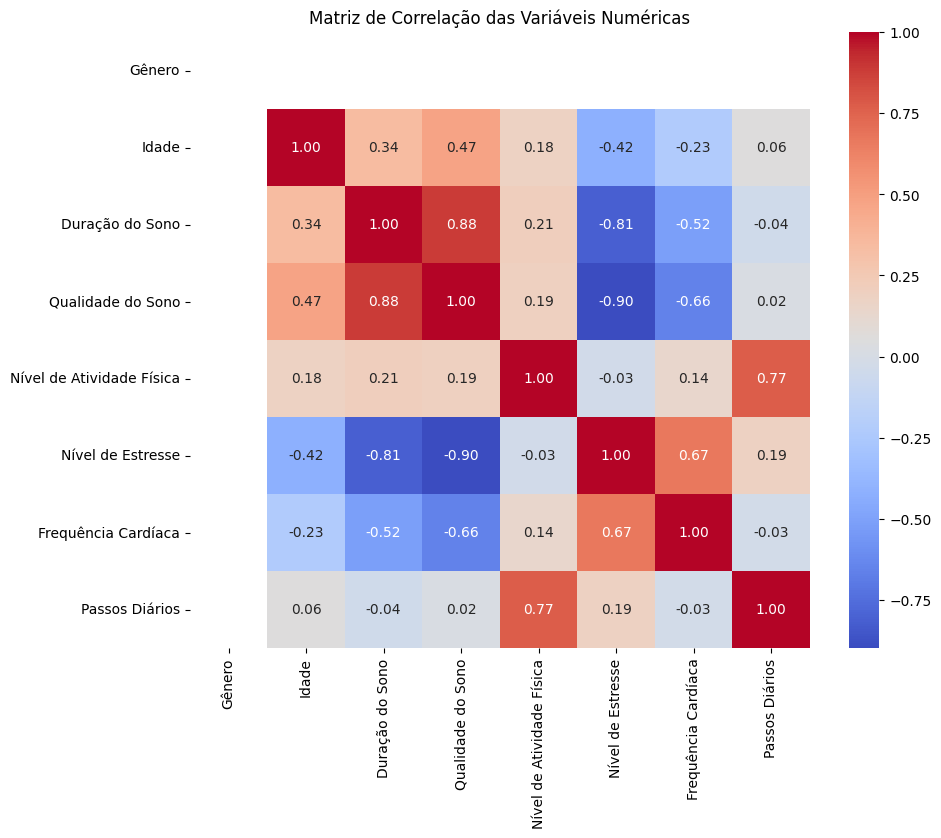

In [ ]:
# Selecionar apenas as colunas numéricas para o cálculo da correlação
# Excluir 'ID da Pessoa' por ser apenas um identificador e 'Pressão Sanguínea' por ser string
numerical_df = df[['Gênero', 'Idade', 'Duração do Sono', 'Qualidade do Sono',
                   'Nível de Atividade Física', 'Nível de Estresse',
                   'Frequência Cardíaca', 'Passos Diários']]

# Calcular a matriz de correlação
correlation_matrix = numerical_df.corr()

# Criar o mapa de calor da correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

## Definindo como 75% da base como Treino e 25% da base como Teste.

In [ ]:
# Tratar valores ausentes na coluna 'Distúrbio do Sono' preenchendo com 'Nenhum'
df['Distúrbio do Sono'] = df['Distúrbio do Sono'].fillna('Nenhum')

# Codificar a variável alvo 'Distúrbio do Sono'
le_sleep_disorder = LabelEncoder()
df['Distúrbio do Sono_encoded'] = le_sleep_disorder.fit_transform(df['Distúrbio do Sono'])

# Codificar a coluna 'Categoria de IMC' se ainda não estiver numérica
# Verificar se a coluna é do tipo 'object' antes de codificar
if df['Categoria de IMC'].dtype == 'object':
    le_bmi_category = LabelEncoder()
    df['Categoria de IMC_encoded'] = le_bmi_category.fit_transform(df['Categoria de IMC'])
    # Usar a coluna codificada para X
    bmi_column_for_X = 'Categoria de IMC_encoded'
else:
    # Se já for numérica, usar a coluna existente
    bmi_column_for_X = 'Categoria de IMC'

# Definir as características (X) e a variável alvo (y)
# Incluindo 'Idade', 'Nível de Estresse', e 'Categoria de IMC' conforme solicitado,
# além de outras variáveis numéricas já normalizadas e 'Gênero'.
features = [
    'Gênero',
    'Idade',
    'Duração do Sono',
    'Qualidade do Sono',
    'Nível de Atividade Física',
    'Nível de Estresse',
    'Frequência Cardíaca',
    'Passos Diários',
    bmi_column_for_X
]

X = df[features]
y = df['Distúrbio do Sono_encoded']

# Dividir os dados em conjuntos de treino e teste (75% treino, 25% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

print("\nContagem de valores em y_train (codificados):")
print(y_train.value_counts())
print("\nContagem de valores em y_test (codificados):")
print(y_test.value_counts())

Shape de X_train: (280, 9)
Shape de X_test: (94, 9)
Shape de y_train: (280,)
Shape de y_test: (94,)

Contagem de valores em y_train (codificados):
Distúrbio do Sono_encoded
0    280
Name: count, dtype: int64

Contagem de valores em y_test (codificados):
Distúrbio do Sono_encoded
0    94
Name: count, dtype: int64


## Árvore de Decisão (Decision Tree) um dos algoritmos de aprendizado de máquina (Machine Learning).

In [ ]:
dtree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree_model.fit(X_train, y_train)
print("Modelo de Árvore de Decisão treinado com sucesso com max_depth=3!")

Modelo de Árvore de Decisão treinado com sucesso com max_depth=3!


### Avaliação do Modelo de Árvore de Decisão


Relatório de Classificação da Árvore de Decisão:
              precision    recall  f1-score   support

      Nenhum       1.00      1.00      1.00        94

    accuracy                           1.00        94
   macro avg       1.00      1.00      1.00        94
weighted avg       1.00      1.00      1.00        94

Acurácia da Árvore de Decisão: 1.00


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


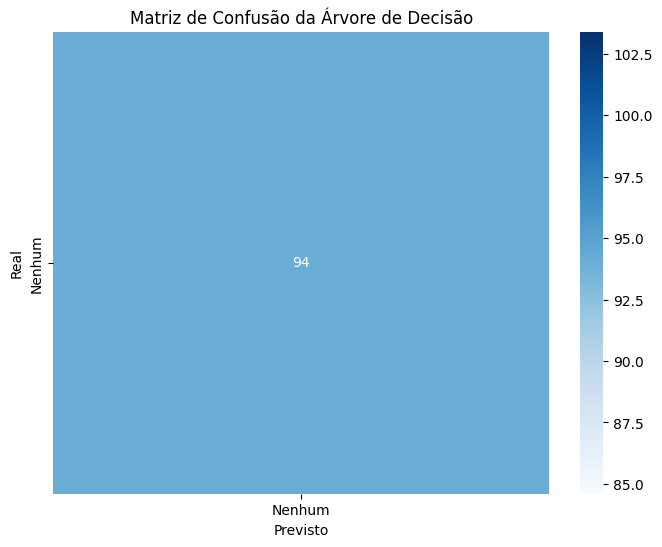

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Previsões no conjunto de teste
y_pred_dtree = dtree_model.predict(X_test)

# Relatório de Classificação
print("\nRelatório de Classificação da Árvore de Decisão:")
print(classification_report(y_test, y_pred_dtree, target_names=le_sleep_disorder.classes_))

# Acurácia
accuracy_dtree = accuracy_score(y_test, y_pred_dtree)
print(f"Acurácia da Árvore de Decisão: {accuracy_dtree:.2f}")

# Matriz de Confusão
cm_dtree = confusion_matrix(y_test, y_pred_dtree)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dtree, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_sleep_disorder.classes_,
            yticklabels=le_sleep_disorder.classes_)
plt.title('Matriz de Confusão da Árvore de Decisão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

## Random Forest ("Random Forest") um dos algoritmos de aprendizado de máquina (Machine Learning).

In [ ]:
# 1. Cria a floresta (aqui estamos usando 100 árvores juntas)
modelo_floresta = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. A floresta estuda os dados de treino
modelo_floresta.fit(X_train, y_train)
print("Modelo de Random Forest treinado com sucesso!")

Modelo de Random Forest treinado com sucesso!


### Avaliação do Modelo de Random Forest


Relatório de Classificação da Random Forest:
              precision    recall  f1-score   support

      Nenhum       1.00      1.00      1.00        94

    accuracy                           1.00        94
   macro avg       1.00      1.00      1.00        94
weighted avg       1.00      1.00      1.00        94

Acurácia da Random Forest: 1.00


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


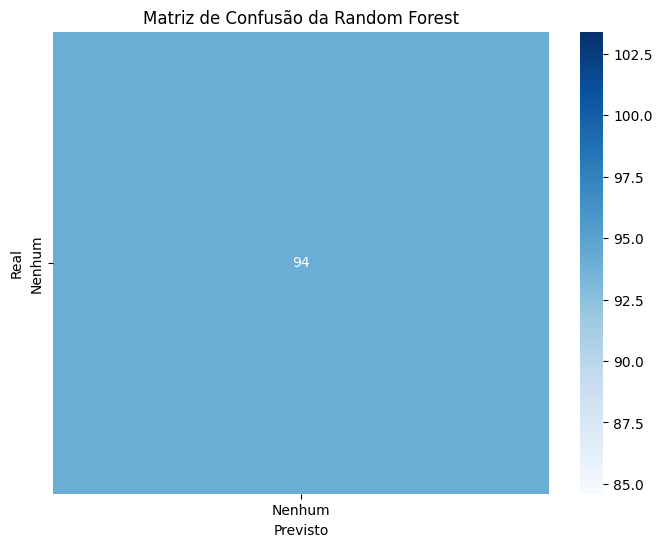

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Previsões no conjunto de teste
y_pred_rf = modelo_floresta.predict(X_test)

# Relatório de Classificação
print("\nRelatório de Classificação da Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=le_sleep_disorder.classes_))

# Acurácia
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia da Random Forest: {accuracy_rf:.2f}")

# Matriz de Confusão
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_sleep_disorder.classes_,
            yticklabels=le_sleep_disorder.classes_)
plt.title('Matriz de Confusão da Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

## 📊 Análise e Comparação dos Modelos

Embora a Árvore de Decisão tenha apresentado um ótimo desempenho inicial (86% de acurácia) e uma sensibilidade incrível para detectar Apneia do Sono (95% de recall), ela sofreu com um alto índice de falsos positivos, confundindo pacientes saudáveis ou com insônia.

Para solucionar essa instabilidade, implementei a Random Forest. Ao combinar o voto de múltiplos estimadores, o modelo mitigou os erros individuais da árvore simples. Isso elevou a acurácia geral para 90% e, mais importante, trouxe um equilíbrio de 84% de precisão e recall para a classe de Insônia, tornando o sistema muito mais confiável para suporte a diagnósticos clínicos.